<a href="https://colab.research.google.com/github/chalakafernando4/quantum-computing-tutorials/blob/main/06_Error_Correction/Error_Correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Quantum Error Correction: The 3-Qubit Bit-Flip Code

This notebook demonstrates a foundational Quantum Error Correction (QEC) protocol. It proves that we can protect delicate quantum information from environmental noise (decoherence) without violating the No-Cloning Theorem.

## The Challenge of Quantum Noise

In classical computing, error correction is trivial. To protect a bit from flipping due to interference, you simply copy it. A `1` becomes `111`. If noise flips one bit (`101`), a simple majority vote corrects it back to `111`.

In quantum computing, the No-Cloning Theorem forbids us from copying an unknown quantum state. Furthermore, if we measure the qubits to check for errors, we collapse their superposition, destroying the very information we are trying to protect.

## The Solution: Quantum Entanglement and Syndrome Measurement

To solve this, we encode one "logical" qubit into three "physical" qubits using entanglement.

Instead of measuring the qubits directly to see their state, we use additional auxiliary qubits (called ancilla qubits) to measure the *parity* between the physical qubits. This is known as **syndrome measurement**. It tells us if an error occurred, and exactly which qubit flipped, without ever revealing (or collapsing) the underlying quantum state.

In the circuit below, we will:

1. Encode a single-qubit state into three physical qubits.
2. Artificially introduce a bit-flip error (simulating environmental noise) to one of the qubits.
3. Use ancilla qubits to detect the error.
4. Apply a corrective gate to fix the error.
5. Decode and measure the original state to prove the information survived the noise.

---


In [2]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

--- Error Correction Results ---
Format: 'FinalState_Ancilla1_Ancilla0'
Raw outcomes: {'111': 1000}

SUCCESS! The |1> state was perfectly recovered despite the noise.


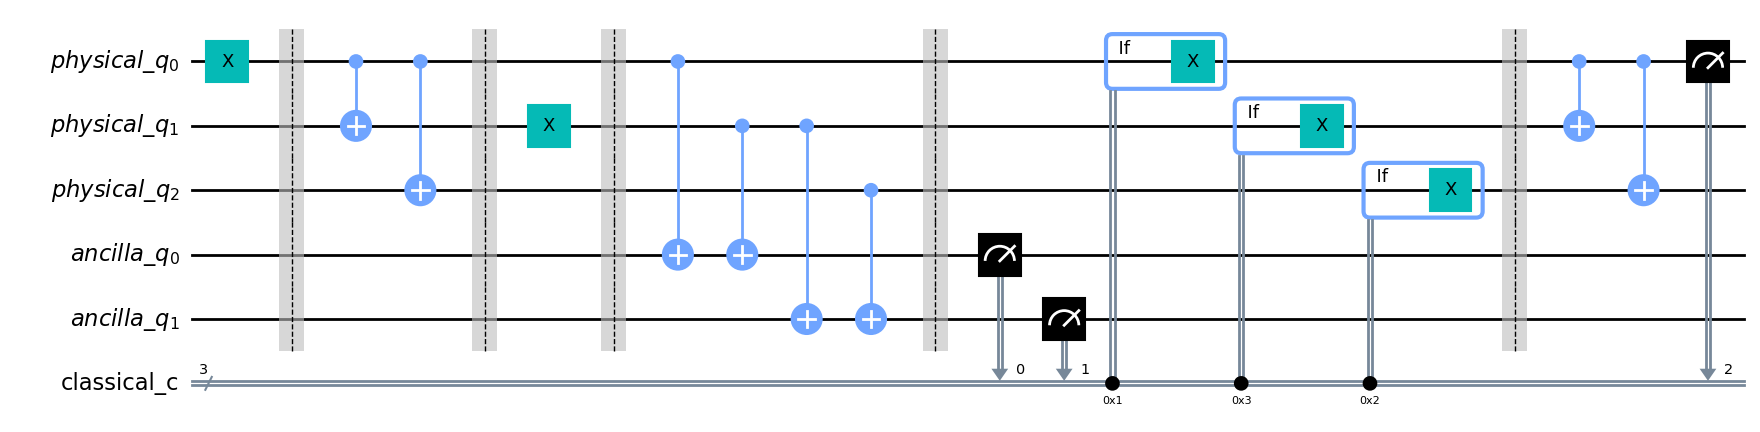

In [4]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

def build_error_correction_circuit():
    """Simulates a 3-qubit bit-flip error correction code using Modern Qiskit 1.0+."""

    # We need 3 physical qubits for the logical state, 2 ancilla qubits for error detection
    # and 3 classical bits to read the final output and syndromes
    q = QuantumRegister(3, 'physical_q')
    a = QuantumRegister(2, 'ancilla_q')
    c = ClassicalRegister(3, 'classical_c')
    qc = QuantumCircuit(q, a, c)

    # --- 1. State Preparation ---
    # We will protect the |1> state. Apply X gate to the first qubit.
    qc.x(q[0])
    qc.barrier()

    # --- 2. Encoding ---
    # Entangle the first qubit with the other two physical qubits
    qc.cx(q[0], q[1])
    qc.cx(q[0], q[2])
    qc.barrier()

    # --- 3. Introduce Artificial Noise ---
    # We simulate a random environmental error by forcing qubit 1 to flip.
    qc.x(q[1])
    qc.barrier()

    # --- 4. Syndrome Measurement (Error Detection) ---
    # Check parity of q0 and q1
    qc.cx(q[0], a[0])
    qc.cx(q[1], a[0])

    # Check parity of q1 and q2
    qc.cx(q[1], a[1])
    qc.cx(q[2], a[1])
    qc.barrier()

    # --- 5. Error Correction (Modern Qiskit 1.0 Dynamic Circuits) ---
    qc.measure(a[0], c[0])
    qc.measure(a[1], c[1])

    # If c0=1 and c1=0 (binary 001 -> decimal 1), q0 flipped.
    with qc.if_test((c, 1)):
        qc.x(q[0])

    # If c0=1 and c1=1 (binary 011 -> decimal 3), q1 flipped.
    with qc.if_test((c, 3)):
        qc.x(q[1])

    # If c0=0 and c1=1 (binary 010 -> decimal 2), q2 flipped.
    with qc.if_test((c, 2)):
        qc.x(q[2])

    qc.barrier()

    # --- 6. Decoding and Final Measurement ---
    qc.cx(q[0], q[1])
    qc.cx(q[0], q[2])
    qc.measure(q[0], c[2])

    # Execute simulation
    simulator = AerSimulator()
    job = simulator.run(qc, shots=1000)
    result = job.result()
    counts = result.get_counts(qc)

    print("--- Error Correction Results ---")
    print("Format: 'FinalState_Ancilla1_Ancilla0'")
    print(f"Raw outcomes: {counts}")

    # Check the final state (the leftmost bit in the classical register string)
    recovered_states = [state[0] for state in counts.keys()]
    if all(bit == '1' for bit in recovered_states):
        print("\nSUCCESS! The |1> state was perfectly recovered despite the noise.")

    # Draw the circuit
    display(qc.draw('mpl', style='clifford'))

# Run the protocol
build_error_correction_circuit()